Data Splitting

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name = "MedHouseValue")

df = X.copy()
df["target"] = y

display(df)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


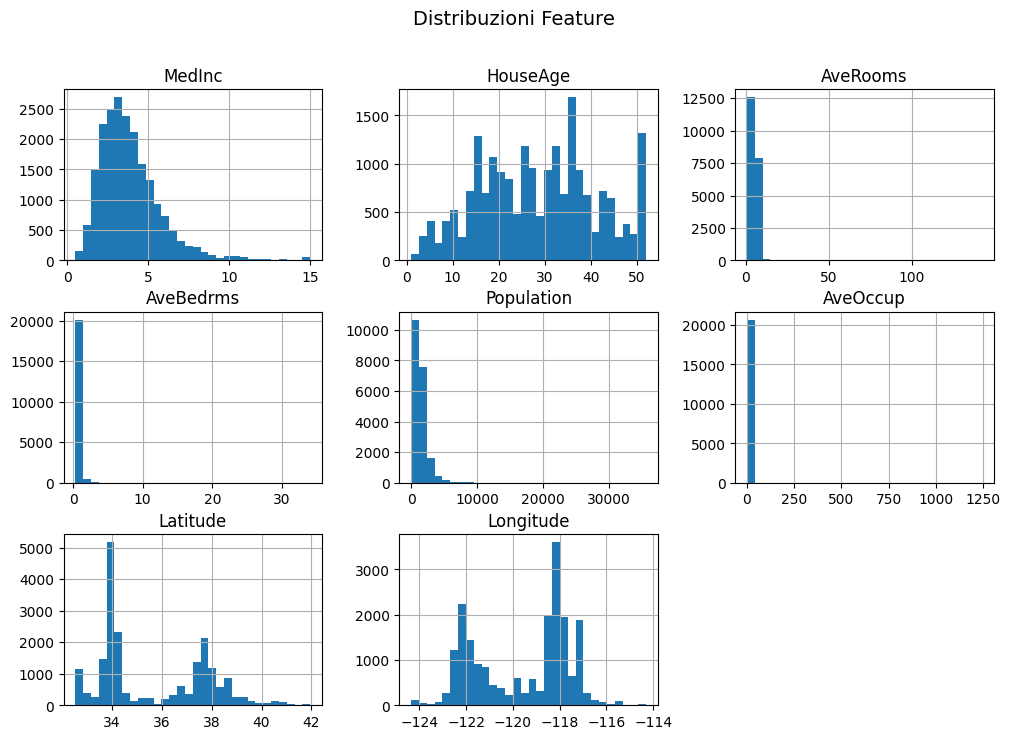

In [ ]:
# andiamo a vedere gli istogrammi delle distribuzioni delle feature

X.hist(bins=30, figsize=(12,8))
plt.suptitle("Distribuzioni Feature", fontsize = 14)
plt.show()

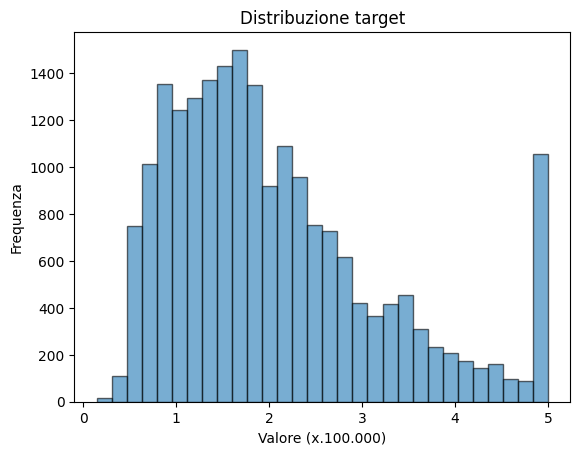

In [ ]:
plt.hist(y, bins=30, edgecolor="black", alpha = 0.6)
plt.title("Distribuzione target")
plt.xlabel("Valore (x.100.000$)")
plt.ylabel("Frequenza")
plt.show()

In [ ]:
# dividiamo il dataset in test set e training set, per evitare che il modello sia influenzato dal data leakage
# sklearn da solo valuta le caratteristiche statistiche del dataset e suddivide i set in base a tutte le righe del dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train Set:\t{X_train.shape}")
print(f"Test Set:\t{X_test.shape}")


Train Set:	(16512, 8)
Test Set:	(4128, 8)


In [7]:
# applichiamo lo scaling dopo la suddivisione

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE TRAINING SET:\t{mse_train:.4}")
print(f"R2 TRAINING SET:\t{r2_train:.4}")
print(f"MSE TEST SET:\t{mse_test:.4}")
print(f"R2 TEST SET:\t{r2_test:.4}")

MSE TRAINING SET:	0.5179
R2 TRAINING SET:	0.6126
MSE TEST SET:	0.5389
R2 TEST SET:	0.5888


In [ ]:
# dal risultato vediamo che il training set ha allenato bene il modello e lo stesso funziona bene anche su i dati di test. Nonostante questo il valore di MSE è abbastanza grande, 
# questo perché il db fetch california housing è molto complesso e serve il feature scaling delle features o l'uso di altri modelli non lineari che catturano meglio
# la non linearità delle relazioni tra i dati 